In [53]:

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from numpy.ma.core import shape
from pandas.conftest import ascending



In [54]:
df = pd.read_csv("data/googleplaystore.csv")

In [55]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [56]:
df.shape

(10841, 13)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [58]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [59]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

### Insights and observations
#### the dataset has missing values

In [60]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [61]:
df['Reviews'].unique()

<StringArray>
[   '159',    '967',  '87510', '215644',    '167',    '178',  '36815',
  '13791',    '121',  '13880',
 ...
   '2036',  '56496', '376223',    '785',   '5775',    '885',  '88486',
    '603',   '1195', '398307']
Length: 6002, dtype: str

In [62]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [63]:
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [64]:
df_copy = df.copy()

In [65]:
df_copy = df_copy.drop(df_copy.index[10472])

In [66]:
df_copy[~df_copy['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [67]:
# convert reviews data type to int
df_copy['Reviews']= df_copy['Reviews'].astype(int)

In [68]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  str    
 5   Installs        10840 non-null  str    
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(1), str(11)
memory usage: 1.2 MB


In [69]:
df_copy['Size'].unique()

<StringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str

In [70]:
df_copy['Size'] = df_copy['Size'].str.replace('M','000')
df_copy['Size'] = df_copy['Size'].str.replace('k','')

In [71]:
list(df_copy['Size'].unique())

['19000',
 '14000',
 '8.7000',
 '25000',
 '2.8000',
 '5.6000',
 '29000',
 '33000',
 '3.1000',
 '28000',
 '12000',
 '20000',
 '21000',
 '37000',
 '2.7000',
 '5.5000',
 '17000',
 '39000',
 '31000',
 '4.2000',
 '7.0000',
 '23000',
 '6.0000',
 '6.1000',
 '4.6000',
 '9.2000',
 '5.2000',
 '11000',
 '24000',
 'Varies with device',
 '9.4000',
 '15000',
 '10000',
 '1.2000',
 '26000',
 '8.0000',
 '7.9000',
 '56000',
 '57000',
 '35000',
 '54000',
 '201',
 '3.6000',
 '5.7000',
 '8.6000',
 '2.4000',
 '27000',
 '2.5000',
 '16000',
 '3.4000',
 '8.9000',
 '3.9000',
 '2.9000',
 '38000',
 '32000',
 '5.4000',
 '18000',
 '1.1000',
 '2.2000',
 '4.5000',
 '9.8000',
 '52000',
 '9.0000',
 '6.7000',
 '30000',
 '2.6000',
 '7.1000',
 '3.7000',
 '22000',
 '7.4000',
 '6.4000',
 '3.2000',
 '8.2000',
 '9.9000',
 '4.9000',
 '9.5000',
 '5.0000',
 '5.9000',
 '13000',
 '73000',
 '6.8000',
 '3.5000',
 '4.0000',
 '2.3000',
 '7.2000',
 '2.1000',
 '42000',
 '7.3000',
 '9.1000',
 '55000',
 '23',
 '6.5000',
 '1.5000',
 '7.500

In [72]:
df_copy['Size'] = df_copy['Size'].replace("Varies with device",np.nan)
df_copy['Size'] = df_copy['Size'].astype(float)

In [73]:
df_copy['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str

In [74]:
df_copy["Price"].unique()

<StringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49',   '$1.29',   '$5.00',  '$13.99', '$299.99', '$379.99',  '$37.99',
  '$18.99', '$389.99',  '$19.90',   '$8.49',   '$1.75',  '$14.00',   '$4.85',
  '$46.99', '$109.99', '$154.99',   '$3.08',   '$2.59',   '$4.80',   '$1.96',
  '$19.40',   '$3.90',   '$4.59',  '$15.46',   '$3.04',   '$4.29',   '$2.60',
   '$3.28',   '$4.60',  '$28.99',   '$2.95',   '$2.90',   '$1.97', '$200.00',
  '$89.99',   '$2.56',  '$30.99',   '$3.61', '$394

In [75]:
char_to_remove = ['+',',','$']
cols_to_clean = ['Installs','Price']
for item in char_to_remove:
    for cols in cols_to_clean:
        df_copy[cols] = df_copy[cols].str.replace(item,'')

In [76]:
df_copy['Installs'] = df_copy['Installs'].str.replace(' ', '', regex=False)


In [77]:
df_copy["Installs"].unique()

<StringArray>
[     '10000',     '500000',    '5000000',   '50000000',     '100000',
      '50000',    '1000000',   '10000000',       '5000',  '100000000',
 '1000000000',       '1000',  '500000000',         '50',        '100',
        '500',         '10',          '1',          '5',          '0']
Length: 20, dtype: str

In [78]:
df_copy['Price'] = df_copy['Price'].str.strip()
df_copy['Price'].unique()

<StringArray>
[     '0',   '4.99',   '3.99',   '6.99',   '1.49',   '2.99',   '7.99',
   '5.99',   '3.49',   '1.99',   '9.99',   '7.49',   '0.99',   '9.00',
   '5.49',  '10.00',  '24.99',  '11.99',  '79.99',  '16.99',  '14.99',
   '1.00',  '29.99',  '12.99',   '2.49',  '10.99',   '1.50',  '19.99',
  '15.99',  '33.99',  '74.99',  '39.99',   '3.95',   '4.49',   '1.70',
   '8.99',   '2.00',   '3.88',  '25.99', '399.99',  '17.99', '400.00',
   '3.02',   '1.76',   '4.84',   '4.77',   '1.61',   '2.50',   '1.59',
   '6.49',   '1.29',   '5.00',  '13.99', '299.99', '379.99',  '37.99',
  '18.99', '389.99',  '19.90',   '8.49',   '1.75',  '14.00',   '4.85',
  '46.99', '109.99', '154.99',   '3.08',   '2.59',   '4.80',   '1.96',
  '19.40',   '3.90',   '4.59',  '15.46',   '3.04',   '4.29',   '2.60',
   '3.28',   '4.60',  '28.99',   '2.95',   '2.90',   '1.97', '200.00',
  '89.99',   '2.56',  '30.99',   '3.61', '394.99',   '1.26',   '1.20',
   '1.04']
Length: 92, dtype: str

In [79]:
df_copy['Installs']=df_copy['Installs'].astype(int)
df_copy['Price']=df_copy['Price'].astype(float)

In [80]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  str    
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10840 non-null  str    
 11  Current Ver     10832 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(3), int64(2), str(8)
memory usage: 1.2 MB


In [81]:
#handling last update feature
df_copy["Last Updated"].unique()

<StringArray>
[   'January 7, 2018',   'January 15, 2018',     'August 1, 2018',
       'June 8, 2018',      'June 20, 2018',     'March 26, 2017',
     'April 26, 2018',      'June 14, 2018', 'September 20, 2017',
       'July 3, 2018',
 ...
  'November 23, 2015',      'June 17, 2012',  'February 27, 2015',
  'December 18, 2013',   'February 6, 2012',  'November 25, 2014',
       'May 19, 2016',   'January 20, 2014',  'February 16, 2014',
     'March 23, 2014']
Length: 1377, dtype: str

In [82]:
df_copy['Last Updated']=pd.to_datetime(df_copy['Last Updated'])
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['year'] = df_copy['Last Updated'].dt.year

In [83]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  str           
 1   Category        10840 non-null  str           
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  str           
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  str           
 9   Genres          10840 non-null  str           
 10  Last Updated    10840 non-null  datetime64[us]
 11  Current Ver     10832 non-null  str           
 12  Android Ver     10838 non-null  str           
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  year            10

In [84]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [85]:
df_copy.to_csv('data/play_store_cleaned_Data.csv')

## Exploratory data analysis

In [86]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [87]:
df_copy[df_copy['App'].duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,year
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,NaN,5000000,Free,0.0,Everyone,Business,2018-02-26,Varies with device,4.0.3 and up,26,2,2018
236,Box,BUSINESS,4.2,159872,NaN,10000000,Free,0.0,Everyone,Business,2018-07-31,Varies with device,Varies with device,31,7,2018
239,Google My Business,BUSINESS,4.4,70991,NaN,5000000,Free,0.0,Everyone,Business,2018-07-24,2.19.0.204537701,4.4 and up,24,7,2018
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37000.0,10000000,Free,0.0,Everyone,Business,2018-07-20,4.1.28165.0716,4.0 and up,20,7,2018
261,join.me - Simple Meetings,BUSINESS,4.0,6989,NaN,1000000,Free,0.0,Everyone,Business,2018-07-16,4.3.0.508,4.4 and up,16,7,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10715,FarmersOnly Dating,DATING,3.0,1145,1.4,100000,Free,0.0,Mature 17+,Dating,2016-02-25,2.2,4.0 and up,25,2,2016
10720,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,2018-07-06,5.2,5.0 and up,6,7,2018
10730,FP Notebook,MEDICAL,4.5,410,60000.0,50000,Free,0.0,Everyone,Medical,2018-03-24,2.1.0.372,4.4 and up,24,3,2018
10753,Slickdeals: Coupons & Shopping,SHOPPING,4.5,33599,12000.0,1000000,Free,0.0,Everyone,Shopping,2018-07-30,3.9,4.4 and up,30,7,2018


In [88]:
df_copy[df_copy.duplicated('App')].shape

(1181, 16)

Observation : dataset has duplicated records

In [89]:
df_copy.drop_duplicates(subset=['App'],keep='first')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,25,7,2017
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,6,7,2018
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up,20,1,2017
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,19,1,2015


In [90]:
df_copy.shape

(10840, 16)

### Explore data

In [91]:
numeric_feature = df_copy.select_dtypes(include=['number']).columns.tolist()

categorical_feature = df_copy.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"We have {len(numeric_feature)} numeric features: {numeric_feature}")
print(f"We have {len(categorical_feature)} categorical features: {categorical_feature}")


We have 8 numeric features: ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Day', 'Month', 'year']
We have 7 categorical features: ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


## Proportion of count data on categorical columns

In [92]:
for col in categorical_feature:
    print(df[col].value_counts(normalize=True)*100)
    print("------------------------------------------")

App
ROBLOX                                               0.083018
CBS Sports App - Scores, News, Stats & Watch Live    0.073794
Duolingo: Learn Languages Free                       0.064570
Candy Crush Saga                                     0.064570
8 Ball Pool                                          0.064570
                                                       ...   
Sya9a Maroc - FR                                     0.009224
Fr. Mike Schmitz Audio Teachings                     0.009224
Parkinson Exercices FR                               0.009224
The SCP Foundation DB fr nn5n                        0.009224
iHoroscope - 2018 Daily Horoscope & Astrology        0.009224
Name: proportion, Length: 9660, dtype: float64
------------------------------------------
Category
FAMILY                 18.190204
GAME                   10.552532
TOOLS                   7.776035
MEDICAL                 4.270824
BUSINESS                4.243151
PRODUCTIVITY            3.911078
PERSONALIZATION  

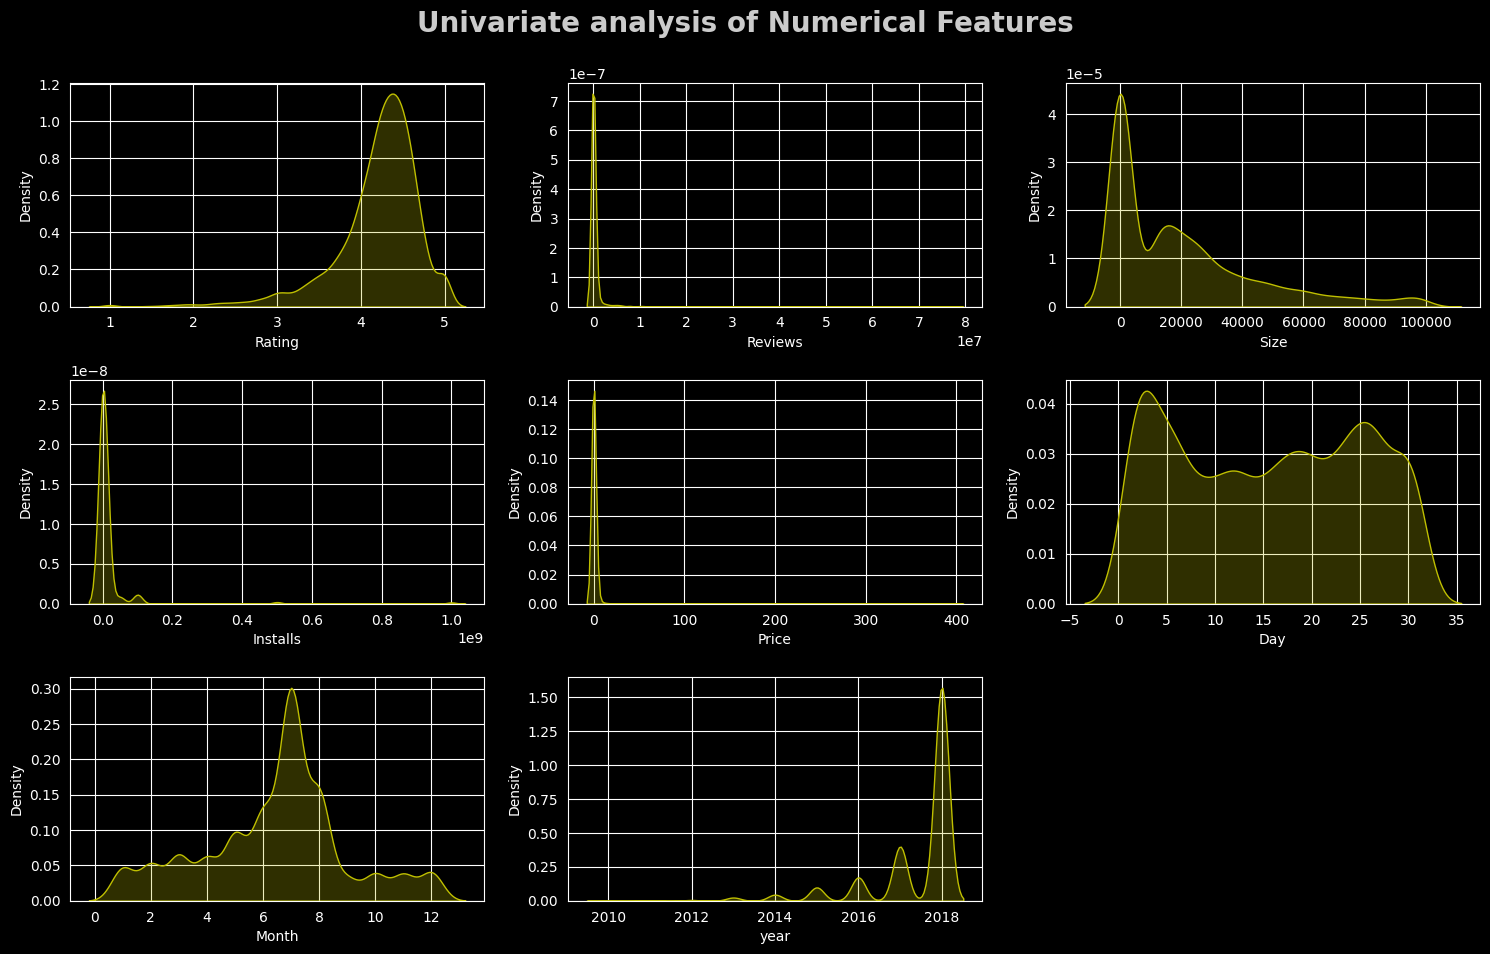

In [93]:
plt.figure(figsize=(15,15))
plt.suptitle('Univariate analysis of Numerical Features',fontsize=20,fontweight='bold',alpha=0.8,y=1.)

for i in range(0,len(numeric_feature)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_copy[numeric_feature[i]],shade=True,color='y')
    plt.xlabel(numeric_feature[i])
plt.tight_layout()
plt.show()

Left skewed : Rating,Year
Right skwed : installs,price,Reviews,size

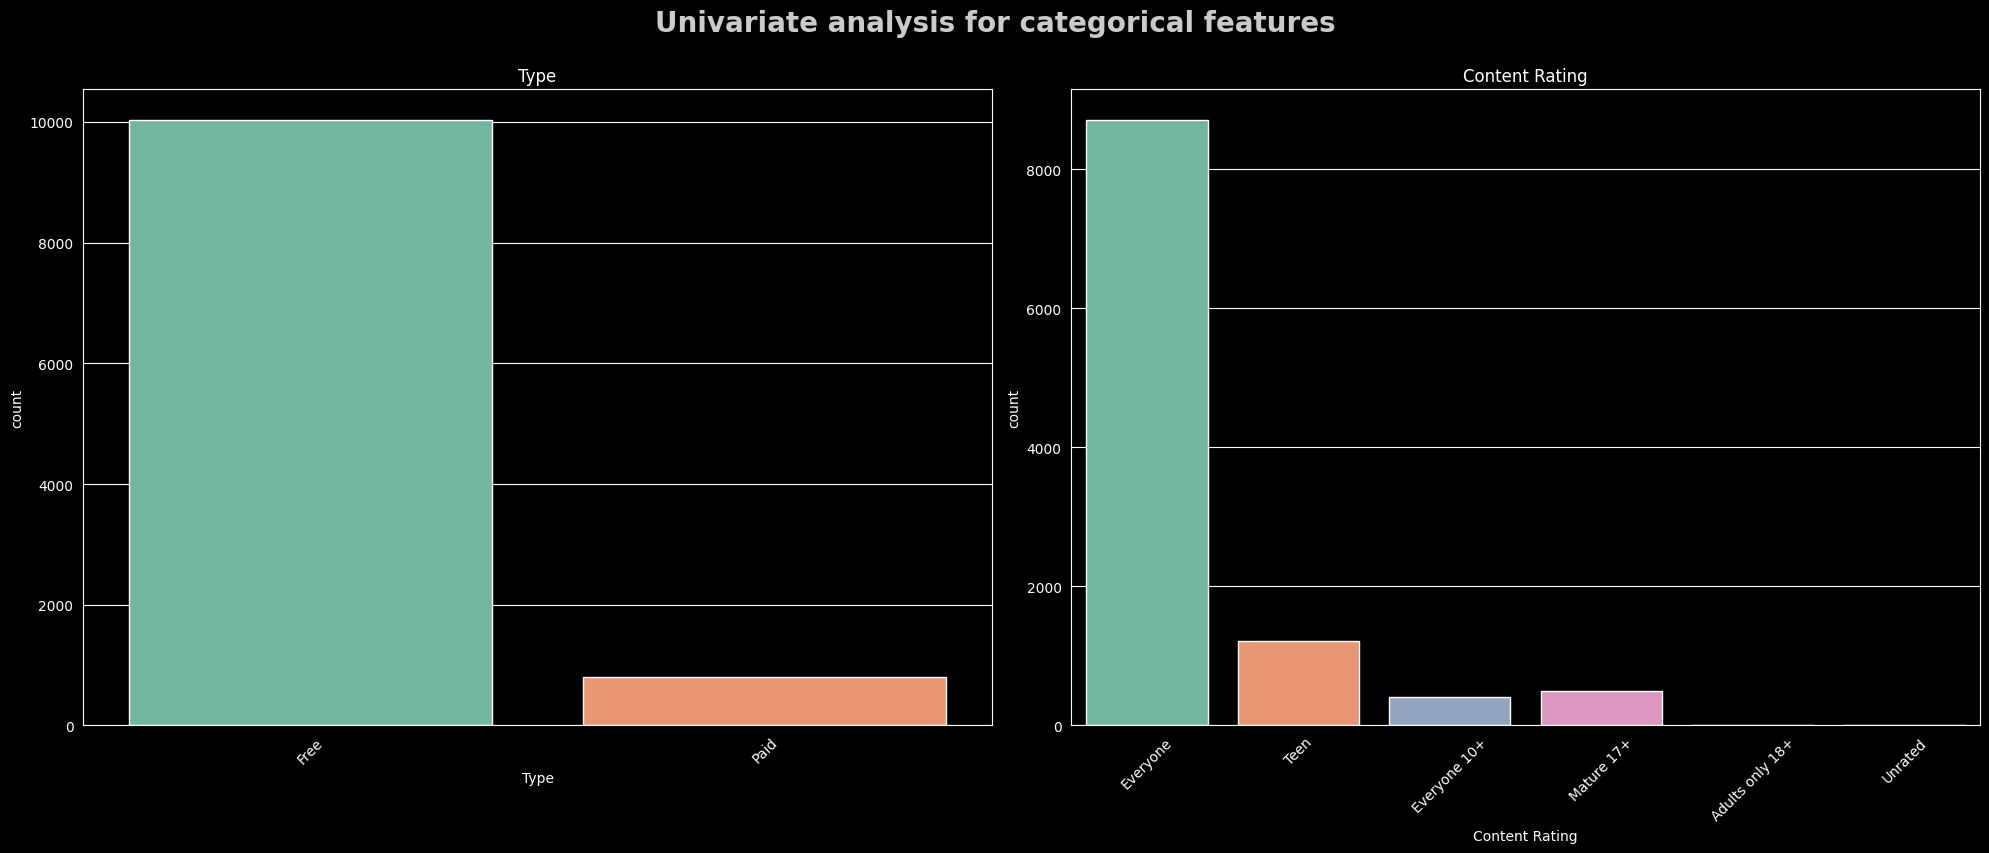

In [94]:
plt.figure(figsize=(20,15))
plt.suptitle("Univariate analysis for categorical features",fontsize=20,fontweight='bold',alpha=0.8,y=1.)
category = ["Type",'Content Rating']
for i in range(0,len(category)):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df_copy[category[i]],palette='Set2')
    plt.title(category[i])
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### which is the most popular app category?

In [95]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


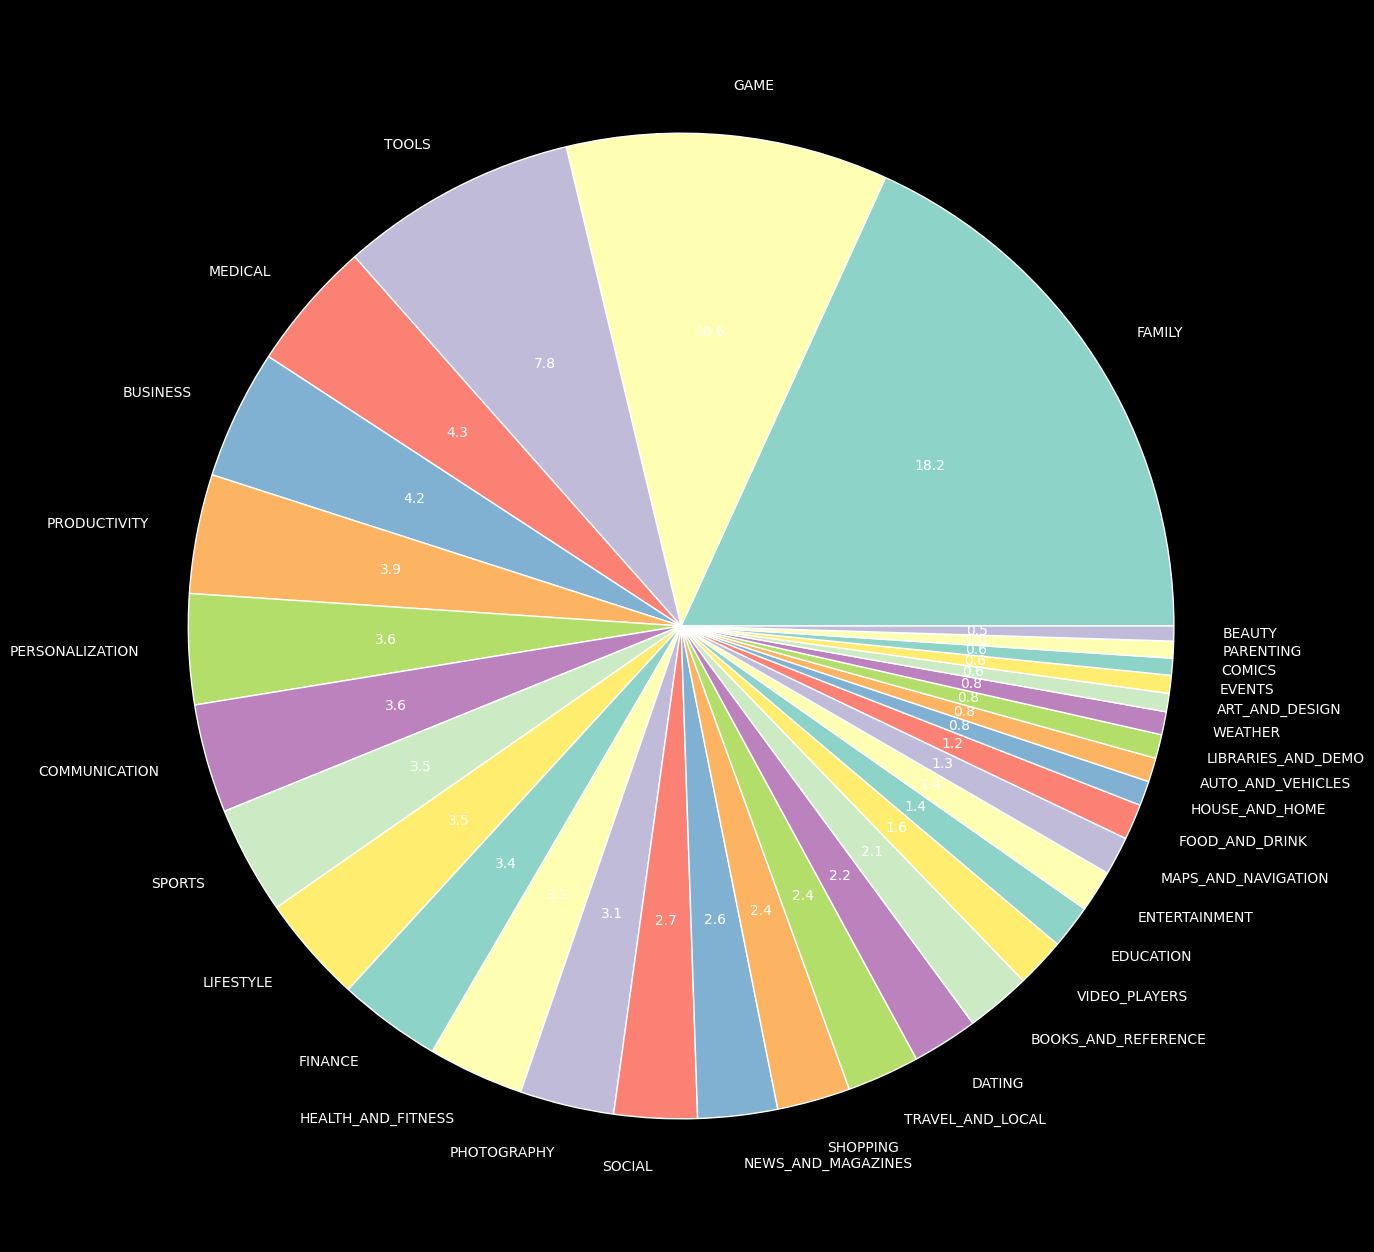

In [96]:
df_copy['Category'].value_counts().plot.pie(y=df['Category'],figsize=(16,16),autopct= "%1.1F")

In [97]:
## observation
category = pd.DataFrame(df['Category'].value_counts())
category.rename(columns={'category':'Count'},inplace=True)

In [98]:
category

,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384


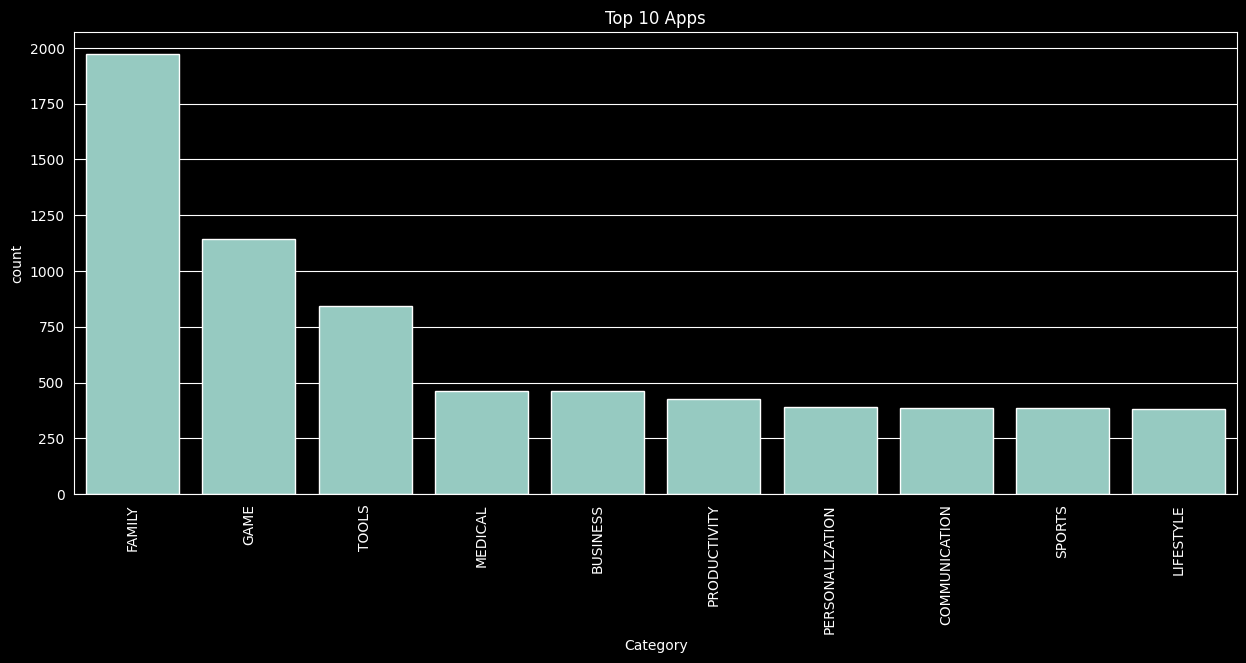

In [99]:
plt.figure(figsize=(15,6))
sns.barplot(x=category.index[:10],y='count',data=category[:10])
plt.title('Top 10 Apps')
plt.xticks(rotation=90)
plt.show()


# assignments
1. largest number of installation
2. top 5 most installed app in every category
3. 5 star rating apps

In [100]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [114]:
largest_installs = df_copy.sort_values(by='Installs',ascending = False)

In [110]:
largest_installs[['Installs','App','Category']].head(1)

,Installs,App,Category
2808,1000000000,Google Photos,PHOTOGRAPHY


In [139]:
top_5 = (df_copy.sort_values(['Category','Installs'],ascending=[True,False]).groupby('Category').head(5))

In [140]:
top_5[['App','Category','Installs']]

,App,Category,Installs
3,Sketch - Draw & Paint,ART_AND_DESIGN,50000000
12,Tattoo Name On My Photo Editor,ART_AND_DESIGN,10000000
19,ibis Paint X,ART_AND_DESIGN,10000000
42,Textgram - write on photos,ART_AND_DESIGN,10000000
45,"Canva: Poster, banner, card maker & graphic de...",ART_AND_DESIGN,10000000
...,...,...,...
3626,The Weather Channel: Rain Forecast & Storm Alerts,WEATHER,50000000
3628,AccuWeather: Daily Forecast & Live Weather Rep...,WEATHER,50000000
3649,"GO Weather - Widget, Theme, Wallpaper, Efficient",WEATHER,50000000
4725,Weather & Clock Widget for Android,WEATHER,50000000


In [145]:
top_5_rating_apps = df_copy[df_copy['Rating'] == 5.0]

In [146]:
top_5_rating_apps[['App','Category','Rating']]

,App,Category,Rating
329,Hojiboy Tojiboyev Life Hacks,COMICS,5.0
612,American Girls Mobile Numbers,DATING,5.0
615,Awake Dating,DATING,5.0
633,Spine- The dating app,DATING,5.0
636,Girls Live Talk - Free Text and Video Chat,DATING,5.0
...,...,...,...
10721,Mad Dash Fo' Cash,GAME,5.0
10742,GKPB FP Online Church,LIFESTYLE,5.0
10776,Monster Ride Pro,GAME,5.0
10820,Fr. Daoud Lamei,FAMILY,5.0
